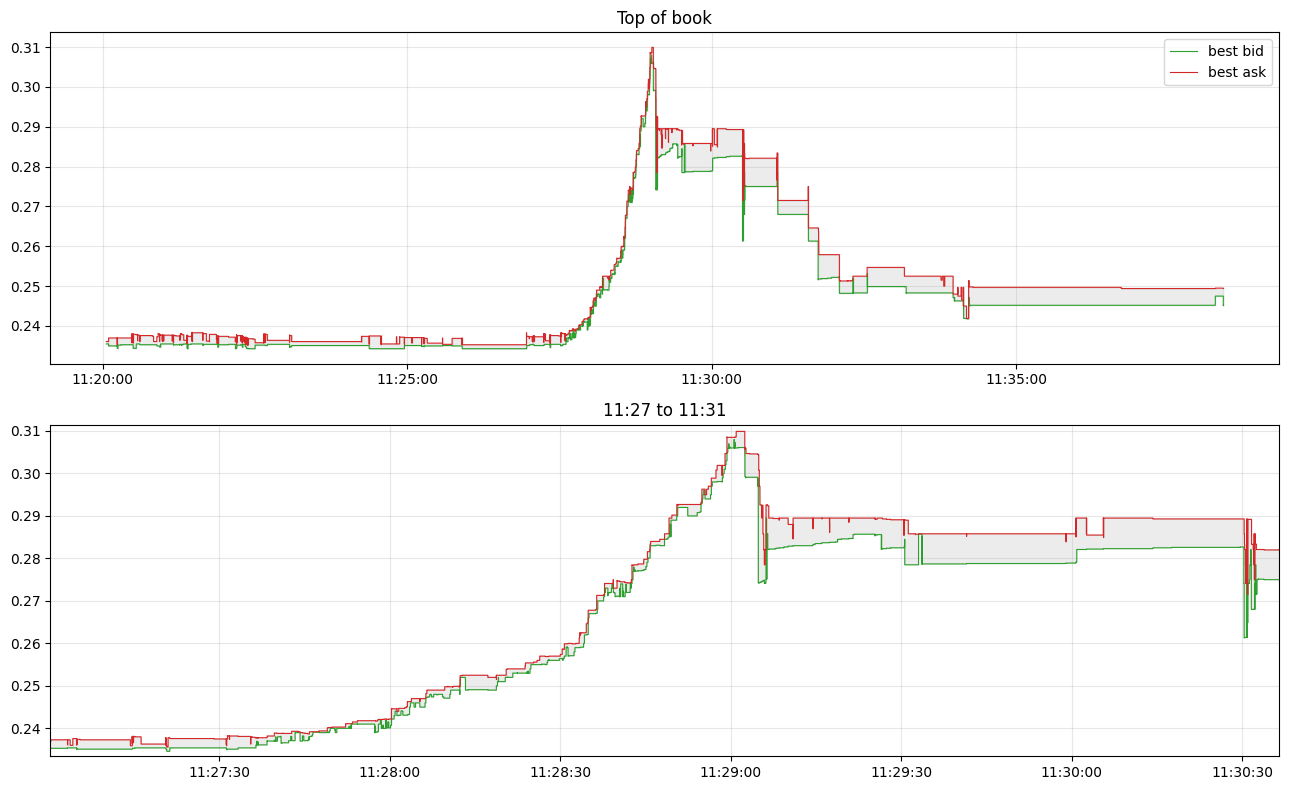

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tob = pd.read_csv(U + 'top_of_book.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts')

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8))

for ax in (a1, a2):
    ax.step(tob.transaction_ts, tob.bid_price, where='post', lw=0.8, color='tab:green', label='best bid')
    ax.step(tob.transaction_ts, tob.ask_price, where='post', lw=0.8, color='tab:red', label='best ask')
    ax.fill_between(tob.transaction_ts, tob.bid_price, tob.ask_price, step='post', alpha=0.15, color='grey')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.grid(True, alpha=0.3)

a1.set_title('Top of book')
a1.legend()

zoom = tob[(tob.transaction_ts >= '2025-04-27 11:27:00') & (tob.transaction_ts <= '2025-04-27 11:31:00')]
a2.set_xlim(zoom.transaction_ts.min(), zoom.transaction_ts.max())
a2.set_ylim(zoom.bid_price.min() * 0.995, zoom.ask_price.max() * 1.005)
a2.set_title('11:27 to 11:31')

plt.tight_layout()
plt.show()

Interaction between public and private trades
Cells P1-P4. Assumes G1's frames are not loaded, so it reloads.

ASSUMPTIONS made in this section, restate them in your report:
1.  private_trades.csv is the complete fill record (34 rows)
2.  public feed excludes our own fills (verified in G3, zero time/price/qty matches) so public side = other people's aggressor flow and our participation is
ours / (ours + public)
3.  clocks across files agree to well under 1s, unverified, all +/- alignment
below inherits this
4. public 'side' is the aggressor side
5. absence of private fills before 11:27:35 is real, not truncation. P1 verifies
     this from the logs, which cover 11:20 onward and show fill events


In [4]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (13, 5)

U = ''  # your data directory
tob = pd.read_csv(U + 'top_of_book.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts').reset_index(drop=True)
pub = pd.read_csv(U + 'public_trades.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts').reset_index(drop=True)
priv = pd.read_csv(U + 'private_trades.csv', parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
tob['mid'] = (tob.bid_price + tob.ask_price) / 2

# verify from logs: any nonzero fill events before the first private trade?
fill_pat = re.compile(r'^(\S+ \S+).*filled ([0-9.]+)@([0-9.]+)')
log_fills = []
with open(U + 'logs.txt') as f:
    for line in f:
        m = fill_pat.match(line)
        if m and float(m.group(2)) > 0:
            log_fills.append(pd.Timestamp(m.group(1)))
log_fills = pd.Series(sorted(set(log_fills)))
print('first fill event in logs:', log_fills.min())
print('first private trade:     ', priv.timestamp.min())
print('log fill events before first private trade:',
      int((log_fills < priv.timestamp.min()).sum()))
# if zero: the algo quoted from 11:20 with NO fills for ~7.5 minutes, then all 34
# fills arrive inside the 2 minute move. fill arrival is entirely concentrated in
# the toxic window, that is the headline of the public/private interaction.

first fill event in logs: 2025-04-27 11:27:35.538298019
first private trade:      2025-04-27 11:27:35.535490048
log fill events before first private trade: 0


In [5]:
# for each private fill: signed public taker flow in the 5s before and 5s after
pub['signed'] = pub.qty.where(pub.side == 'Buy', -pub.qty)

def flow(t0, t1):
    m = (pub.transaction_ts >= t0) & (pub.transaction_ts < t1)
    return pub.loc[m, 'signed'].sum()

rows = []
for _, f in priv.iterrows():
    rows.append(dict(t=f.timestamp, side=f.side, price=f.price, qty=f.qty,
                     flow_pre_5s=flow(f.timestamp - pd.Timedelta('5s'), f.timestamp),
                     flow_post_5s=flow(f.timestamp, f.timestamp + pd.Timedelta('5s'))))
inter = pd.DataFrame(rows)
print('mean signed public flow around our fills (positive = net aggressor buying):')
print(inter.groupby('side')[['flow_pre_5s', 'flow_post_5s']].mean().round(1))
# read: SELL rows with big positive flow_pre = our offers were consumed inside
# aggressive buy bursts. BUY rows with negative flow_pre or flow_post = someone
# dumped into our bids, look especially at the largest fills near the top.
print('\nlargest 5 fills with their surrounding flow:')
print(inter.nlargest(5, 'qty').to_string(index=False))

mean signed public flow around our fills (positive = net aggressor buying):
      flow_pre_5s  flow_post_5s
side                           
BUY          71.4         312.7
SELL        218.2         376.0

largest 5 fills with their surrounding flow:
                            t side  price     qty  flow_pre_5s  flow_post_5s
2025-04-27 11:29:02.457684992  BUY 0.2993 9038.53      -184.97       -302.83
2025-04-27 11:29:02.457668096  BUY 0.3014  964.82      -184.97       -302.83
2025-04-27 11:29:30.466705152 SELL 0.2854  493.02         0.00         20.91
2025-04-27 11:28:38.374288128  BUY 0.2712  174.14       669.66       -205.51
2025-04-27 11:28:52.421449984  BUY 0.2902  109.54       109.98        279.81


In [6]:
priv['ms_group'] = priv.timestamp.dt.floor('ms')
same_ms = priv.groupby('ms_group').filter(lambda g: len(g) > 1)
print('fills sharing the same millisecond:')
print(same_ms[['timestamp', 'side', 'price', 'qty', 'exchange_order_id']].to_string(index=False))
# simultaneous fills at different prices = the market sweeping through several of
# our layered quotes in one shot, note when these happen relative to the top

dup_oid = priv[priv.duplicated('exchange_order_id', keep=False)]
print('\nsame order filled more than once:')
print(dup_oid[['timestamp', 'side', 'price', 'qty', 'exchange_order_id']].to_string(index=False))

tiny = priv[priv.qty <= 0.1]
print('\nresidual dust fills (qty <= 0.1):')
print(tiny[['timestamp', 'side', 'price', 'qty']].to_string(index=False))

fills sharing the same millisecond:
                    timestamp side  price     qty  exchange_order_id
2025-04-27 11:29:02.457639936  BUY 0.3058    9.82       828977435103
2025-04-27 11:29:02.457668096  BUY 0.3014  964.82       828977430144
2025-04-27 11:29:02.457684992  BUY 0.2993 9038.53       828977435113
2025-04-27 11:29:05.909607936  BUY 0.2744   10.94       828977459706
2025-04-27 11:29:05.909625088  BUY 0.2744   10.94       828977459746
2025-04-27 11:29:30.600777984  BUY 0.2826   10.62       828977554501
2025-04-27 11:29:30.600798208  BUY 0.2826   10.62       828977561760
2025-04-27 11:29:30.600808192  BUY 0.2810   10.68       828977576308
2025-04-27 11:29:30.600829952  BUY 0.2793   49.18       828977561786

same order filled more than once:
                    timestamp side  price   qty  exchange_order_id
2025-04-27 11:27:42.550287104 SELL 0.2388 42.08       828977024450
2025-04-27 11:27:42.750388992 SELL 0.2390  0.01       828977024450
2025-04-27 11:28:20.492658944 SELL 0.2

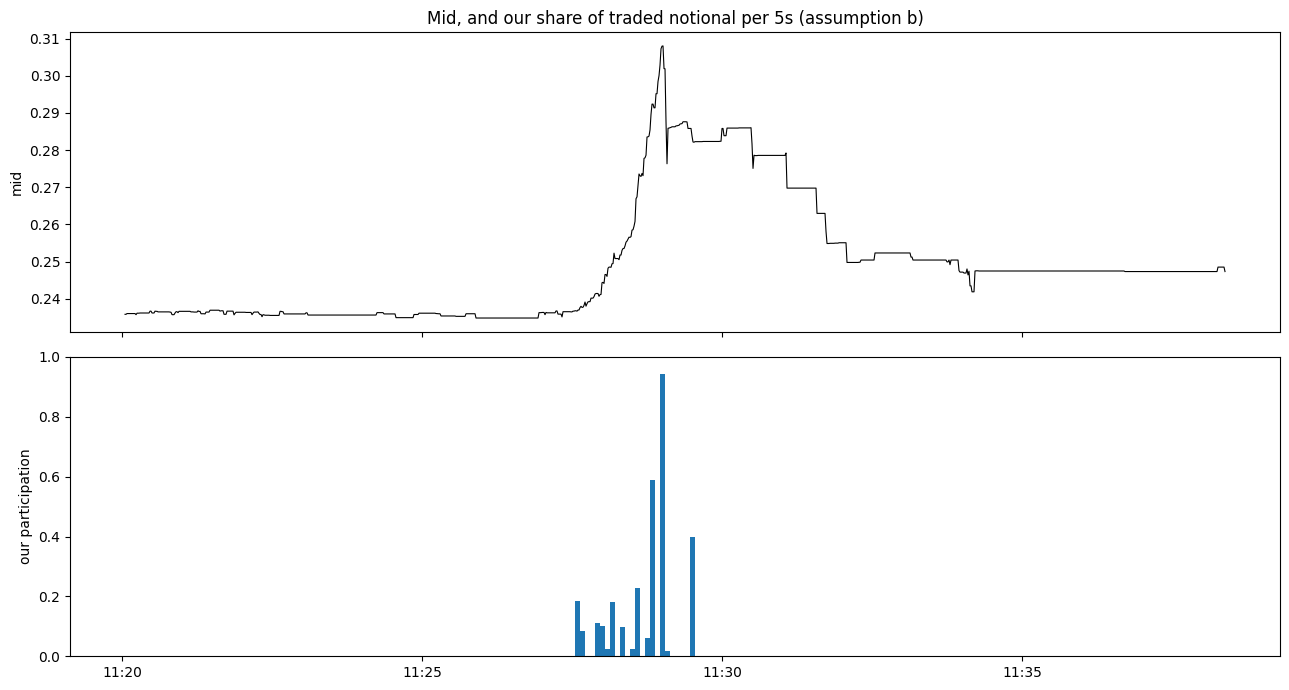

In [9]:
b = '5s'
ours = priv.set_index('timestamp').qty.mul(priv.set_index('timestamp').price).resample(b).sum()
theirs = pub.set_index('transaction_ts').assign(n=lambda d: d.qty * d.price).n.resample(b).sum()
part = (ours / (ours + theirs)).fillna(0)

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 7))
mid_s = tob.set_index('transaction_ts').mid.resample('1s').last().ffill()
a1.plot(mid_s.index, mid_s.values, lw=0.8, color='k')
a1.set_ylabel('mid')
a1.set_title('Mid, and our share of traded notional per 5s (assumption b)')
a2.bar(part.index, part.values, width=pd.Timedelta(b) / pd.Timedelta('1D'), color='tab:blue')
a2.set_ylabel('our participation')
a2.set_ylim(0, 1)
a2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()
# spikes toward 1 mean intervals where almost all volume was people trading
# against us specifically, worth cross-referencing with the largest fills in P2

okay so what do we actually see here.

**The 11:29:02.457 millisecond is the main period of trading**. Three of the layered bids at 0.3058, 0.3014, 0.2993 were swept top down in a single millisecond (blast trade) for around 3k USD notional and what was the peak of the spot. Net public flow was -185 pre trade and -303 post trade. So someone sold 10k to Lo-tech and the public book barely shifted (you would expect some slippage down for this size on this shallow of an order book). The sellers aggression against us you cant see on the public trades so any algo trying to detect this toxic flow would need to consume the private trades.

**The sells on way up are the opposite** SELL row shows +218 mean flow in the 5s before and +376 after (ie lo techs offers were consumer inside aggressive buy bursts and buying continued after each one, so every sell marked out negatively. Sold cheap into the rally and bought size at the top (adversely selected in both direction).

**The 11:29:30 rows look like a second sweep**. Four bids from 0.2826 down to 0.2793 taken in 1 millisecond. and 134ms before that 493 unit sell at 0.2854 with almost no public flow around it. the 0.2826 apir and earlier 10.94 pair at 11:29:05 are same price and same millisecond but with different order ids. it looks like the algo runs at least two orders per side at the same time, which matches the other wave spoken about above.

the double order fill ..227176 is tow partial fills 158ms apart summing to 69.57 which in the log files says 69.57@0.2539 (this agrees, good, but is split in the trades .csv files).



